# Libaries

In [1]:
#General
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import randint

#Data fetching
from pathlib import Path
import tarfile
import requests

#Data Exploring
from pandas.plotting import scatter_matrix

#Data splitting
from sklearn.model_selection import StratifiedShuffleSplit

#Data Preprocessing
import sklearn
sklearn.set_config(display='diagram')
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.pipeline import Pipeline, make_pipeline

#Transform numeric and categorical data with one transformation pipeline
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer

#Model training
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV


# Loading the data

In [2]:
def load_housing_data():
    tarball_path = Path('datasets/housing.tgz')

    if not tarball_path.is_file():
        Path('datasets').mkdir(parents=True, exist_ok=True)
        url = 'https://github.com/ageron/data/raw/main/housing.tgz'

        r = requests.get(url, stream=True)
        r.raise_for_status()

        with open(tarball_path, 'wb') as f:
            f.write(r.raw.read())

        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path='datasets')
    
    return pd.read_csv('datasets/housing/housing.csv')

In [3]:
df = load_housing_data()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


total_bedrooms has missing values

In [5]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


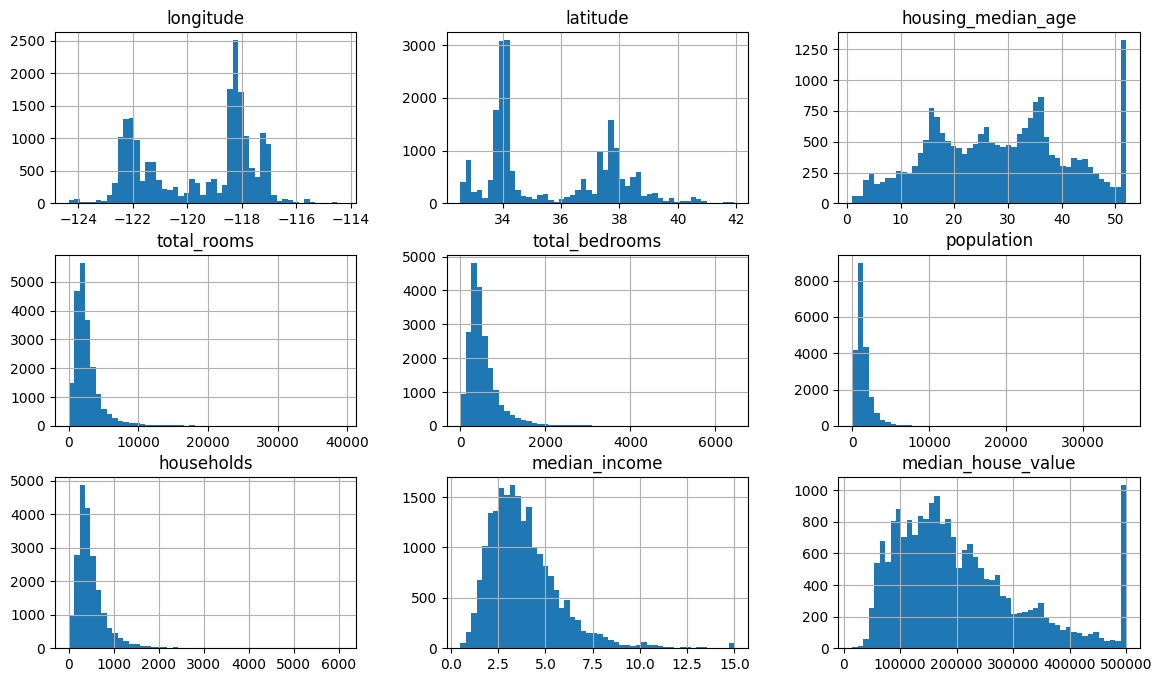

In [7]:
df.hist(bins=50, figsize=(14, 8))
plt.show()

- median_income, median_house_age and median_house_value are capped
- median income is a factor of 10k dollars
- many histogrrams are right skewed --> May be a problem for some algorithms, a more bell shape is preferred

# Training and Test Set Creation

stratified sampling ensures balance for given attributes in the test and training set. For us the median income seems pretty important

## Create a income categroy

In [8]:
df['income_cat'] = pd.cut(df['median_income'], bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5])
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


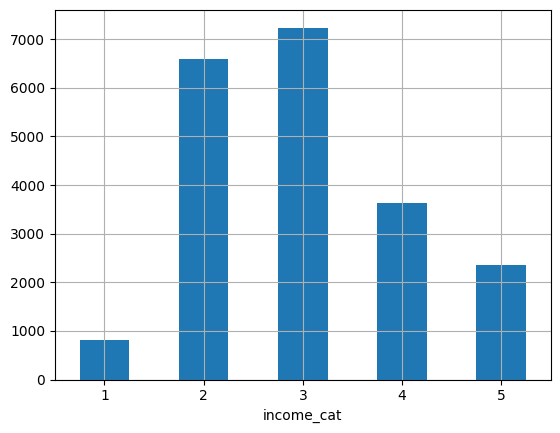

In [9]:
income_cat_counts = df['income_cat'].value_counts().sort_index()
income_cat_counts.plot.bar(rot=0, grid=True)
plt.show()


- This income bins represnet the distributen quite well

In [ ]:
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

strat_splits = []
for train_idx, test_idx in splitter.split(X=df, y=df['income_cat']): #Stratification is done based on y
    stratified_train_set_n = df.iloc[train_idx]
    stratified_test_set_n = df.iloc[test_idx]
    strat_splits.append([stratified_train_set_n, stratified_test_set_n])

stratified_train_set, stratified_test_set = strat_splits[0]

### Checking the strata results in the different sets

In [11]:
df['income_cat'].value_counts() / len(df)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [12]:
stratified_train_set['income_cat'].value_counts() / len(stratified_train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [13]:
stratified_test_set['income_cat'].value_counts() / len(stratified_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [14]:
for set_ in (stratified_train_set, stratified_test_set):
    set_.drop('income_cat', axis=1, inplace=True)

## Data Exploration

In [15]:
housing = stratified_train_set.copy()

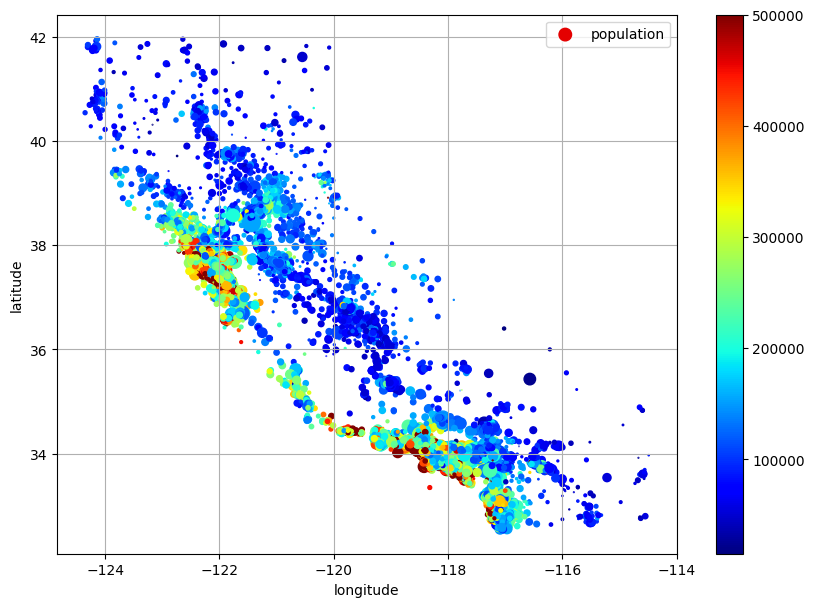

In [16]:
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True,
             s=housing['population'] / 100,
             c=housing['median_house_value'], cmap='jet', colorbar=True,
             legend=True, sharex=False, figsize=(10, 7), label='population')
plt.show()

## Correlations

In [17]:
corr_matrix = housing.corr(numeric_only=True)

In [18]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

- median_income is highly positive correlated
- longitude (East/West) does not really influence
- latitude (North/south) is moderatly correlated. The more south you go the higher the house value

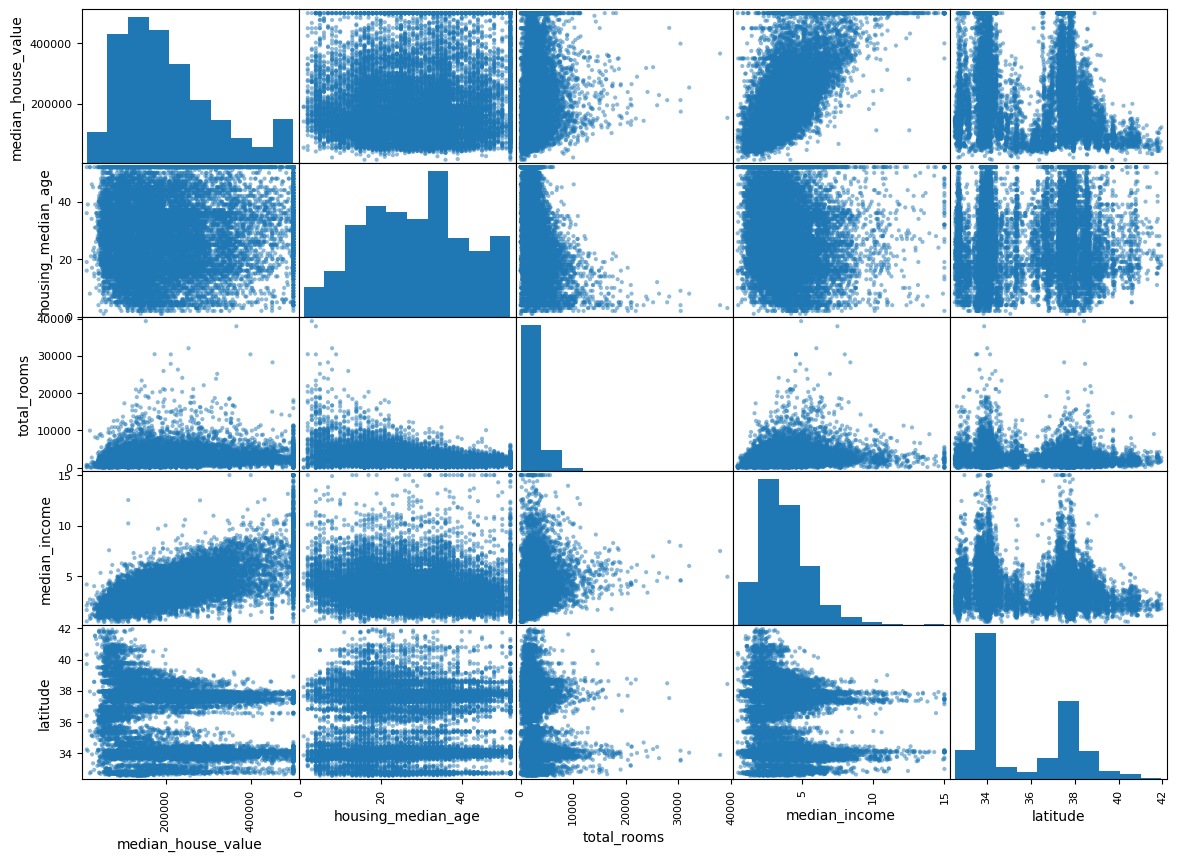

In [19]:

attributes = ['median_house_value', 'housing_median_age', 'total_rooms', 'median_income', 'latitude']
housing[attributes]
scatter_matrix(housing[attributes], figsize=(14,10))
plt.show()

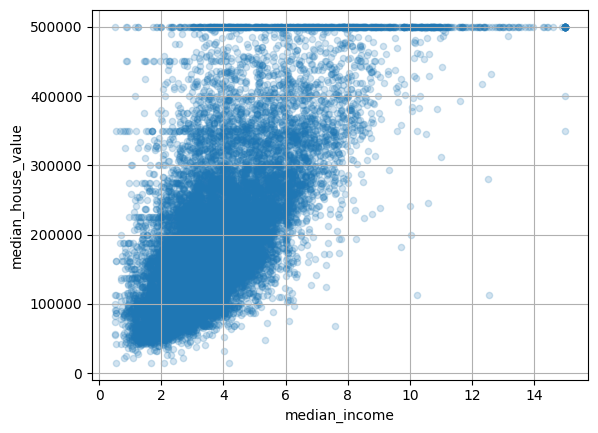

In [20]:
housing.plot(kind='scatter', x='median_income', y='median_house_value', alpha=0.2, grid=True)
plt.show()

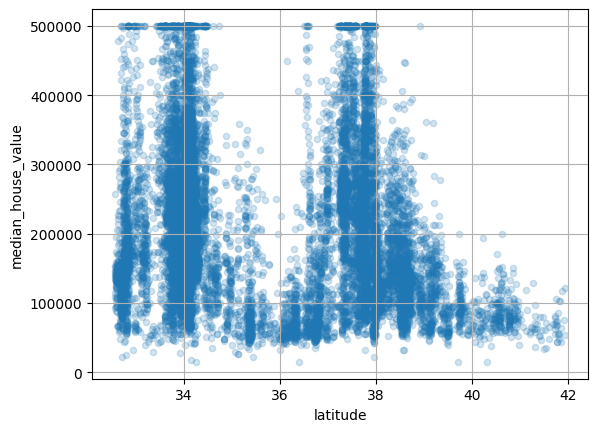

In [21]:
housing.plot(kind='scatter', x='latitude', y='median_house_value', alpha=0.2, grid=True)
plt.show()

## Feature Engineering

In [22]:
housing['rooms_per_houshold'] = housing['total_rooms'] / housing['households']
housing['bedrooms_ratio'] = housing['total_bedrooms'] / housing['total_rooms']
housing['people_per_house'] = housing['population'] / housing['households']

#Done later with rbf Kernel!!
housing['distance_to_SF'] = np.sqrt((housing['latitude'] - 37.77)**2 + (housing['longitude'] - (-122.42))**2)
housing['distance_to_LA'] = np.sqrt((housing['latitude'] - 34.05)**2 + (housing['longitude'] - (-118.24))**2)

In [23]:
housing.corr(numeric_only=True)['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_houshold    0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
distance_to_SF       -0.044412
longitude            -0.050859
distance_to_LA       -0.112385
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

## Data Preprocessing

In [24]:
housing = stratified_train_set.drop('median_house_value', axis=1)
housing_labels = stratified_train_set['median_house_value'].copy()

### Imputing numerical values

In [25]:
imputer = SimpleImputer(strategy='median')

housing_num = housing.select_dtypes(include=[np.number])

imputer.fit(housing_num)

print(imputer.feature_names_in_)
print(imputer.statistics_)

X = imputer.transform(housing_num)

X


['longitude' 'latitude' 'housing_median_age' 'total_rooms'
 'total_bedrooms' 'population' 'households' 'median_income']
[-118.51     34.26     29.     2125.      434.     1167.      408.
    3.5385]


array([[-1.2242e+02,  3.7800e+01,  5.2000e+01, ...,  1.5760e+03,
         1.0340e+03,  2.0987e+00],
       [-1.1838e+02,  3.4140e+01,  4.0000e+01, ...,  6.6600e+02,
         3.5700e+02,  6.0876e+00],
       [-1.2198e+02,  3.8360e+01,  3.3000e+01, ...,  5.6200e+02,
         2.0300e+02,  2.4330e+00],
       ...,
       [-1.1706e+02,  3.2590e+01,  1.3000e+01, ...,  2.8140e+03,
         7.6000e+02,  4.0616e+00],
       [-1.1840e+02,  3.4060e+01,  3.7000e+01, ...,  1.7250e+03,
         8.3800e+02,  4.1455e+00],
       [-1.2241e+02,  3.7660e+01,  4.4000e+01, ...,  6.8200e+02,
         2.1200e+02,  3.2833e+00]], shape=(16512, 8))

### Handling categorical values

In [26]:
housing_cat = housing[['ocean_proximity']]

In [27]:
ordinal_encoder = OrdinalEncoder()
cat_ordinal_encoded = ordinal_encoder.fit_transform(housing_cat)
print(ordinal_encoder.categories_)
cat_ordinal_encoded

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


array([[3.],
       [0.],
       [1.],
       ...,
       [4.],
       [0.],
       [4.]], shape=(16512, 1))

In [28]:
one_hot_encoder = OneHotEncoder()
cat_one_hot = one_hot_encoder.fit_transform(housing_cat)
print(one_hot_encoder.categories_)

cat_one_hot_df = pd.DataFrame(cat_one_hot.toarray(), index=housing.index, columns=one_hot_encoder.get_feature_names_out())



[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


### Feature Scaling
Apply fit() or fit_transform() for scaling only on the training set! on the validation or test set just call transform() and user the learned estimations from the training set!

In [29]:
#Min Max Scaling --> bad for outliers (NORMALIZATION) --> between 0 and 1
min_max_scaler = MinMaxScaler()
X_min_max = min_max_scaler.fit_transform(housing_num)

In [30]:
#Standard Scaler (STANDARTIZATION) --> around mean 0 with std dev of 1
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(housing_num)

### Dealing with tailed distributions
before scaling some heavily tailed distributions should be transformed, to be more symmetric (population)

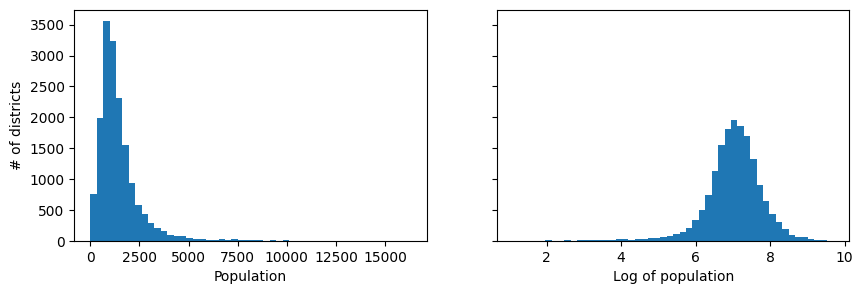

In [31]:
population = housing[['population']].copy()
population['log'] = population.apply(np.log)

population.head()

fig, axes = plt.subplots(nrows = 1, ncols = 2, sharey=True, figsize=(10, 3))
axes[0].hist(population['population'], bins=50)
axes[0].set_xlabel('Population')
axes[0].set_ylabel('# of districts')

axes[1].hist(population['log'], bins=50)
axes[1].set_xlabel('Log of population')

plt.show()

The natural log of the population is a symmetric normal distribution! Need more investigation why it is better for an ML algorithm to work with normally distributed features!

### Handle multimodal distributions
- Bucketize the values and treat the buckets as categories --> OneHotEncoder
- Create single features for the different modes using a similarity function --> rbf_kernel. Example housing_median_age:

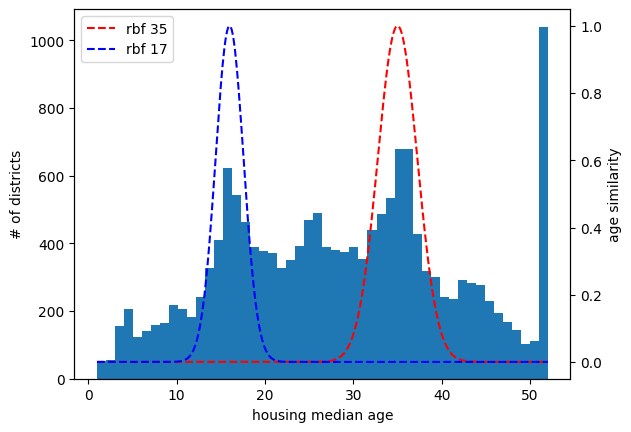

In [32]:
ages_x = np.linspace(
    housing['housing_median_age'].min(),
    housing['housing_median_age'].max(),
    500).reshape(-1, 1)


age_simil_35 = rbf_kernel(ages_x, [[35]], gamma=0.1)
age_simil_17 = rbf_kernel(ages_x, [[16]], gamma=0.2)

fig, ax1 = plt.subplots()
ax1 = housing['housing_median_age'].plot(kind='hist', bins=50)
ax1.set_ylabel('# of districts')
ax1.set_xlabel('housing median age')

ax2 = ax1.twinx()
ax2.plot(ages_x, age_simil_35, color='red', linestyle='--', label='rbf 35')
ax2.plot(ages_x, age_simil_17, color='blue', linestyle='--', label='rbf 17')
ax2.set_ylabel('age similarity')

plt.legend(loc='upper left')
plt.show()

## Custom Transformers

#### Function Transformer

In [33]:
# inverse function is optional when using a TransformedTargetRegressor later
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_population = log_transformer.transform(housing[['population']])

In [34]:
rbf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[[35.]], gamma=0.1))
age_sim_35 = rbf_transformer.transform(housing[['housing_median_age']])

In [35]:
# RBF kernel can also measure the eucledian distance to multiple features --> perfect for measuring distance to SAN FRANCISCO
SF_COORD = [37.7749, -122.41]

sf_rbf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[SF_COORD], gamma=0.1))
sf_sim = sf_rbf_transformer.transform(housing[['latitude', 'longitude']])


In [36]:
# Creating feature ratio
# X[:, [0]] -> returns 2D array
# X[:, 0]   -> returns 1D array
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(np.array([[1, 2], [3, 4]]))

array([[0.5 ],
       [0.75]])

## KMEANS + RBF for Cluster similarity

In [37]:
from sklearn.cluster import KMeans

class ClusterSimilarityTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=0.1, random_state=42):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        # clusters are learned during the fit and can be used in the transform later
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self #always return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]
    
cluster_similarity_transformer = ClusterSimilarityTransformer(gamma=1.)
cluster_sim = cluster_similarity_transformer.fit_transform(housing[['latitude', 'longitude']])

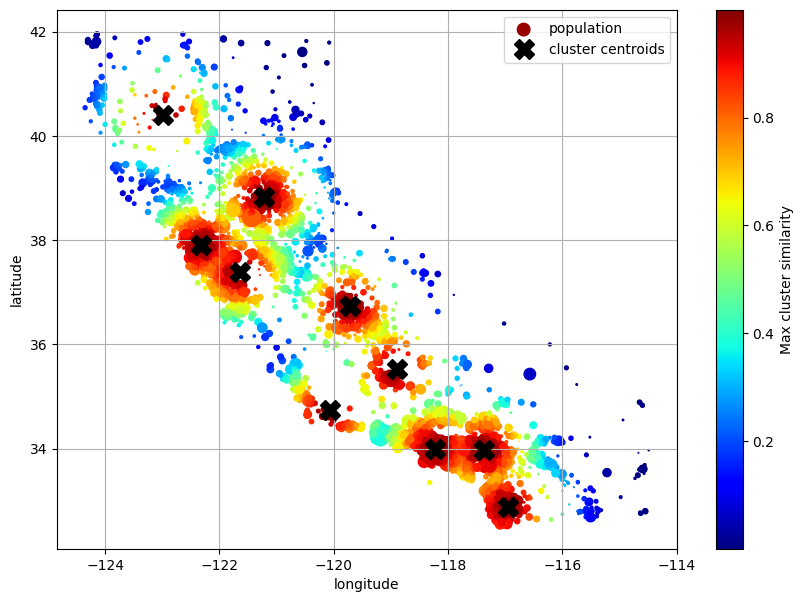

In [38]:
housing_full = pd.concat([housing, housing_labels], axis=1)
housing_full['Max cluster similarity'] = cluster_sim.max(axis=1)

axes = housing_full.plot(kind='scatter', x='longitude', y='latitude', grid=True,
            s=housing_full['population'] / 100,
            c="Max cluster similarity", cmap='jet', colorbar=True,
            legend=True, sharex=False, figsize=(10, 7), label='population')

axes.plot(
    cluster_similarity_transformer.kmeans_.cluster_centers_[:, 1], 
    cluster_similarity_transformer.kmeans_.cluster_centers_[:, 0],
    linestyle='', 
    marker="X",
    color='black',
    markersize=15,
    label='cluster centroids')

plt.legend()
plt.show()

## Transformation Pipelines

In [39]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('standardizer', StandardScaler())
])

#names after class (with prefix if multiple impter_1 e.g.)
convinient_num_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())

In [40]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[0:2].round(2)

#Or as a Data frame
df_housing_num_prepared = pd.DataFrame(housing_num_prepared, columns=num_pipeline.get_feature_names_out(), index=housing_num.index)

In [41]:
#num_pipeline[0]
num_pipeline[-1]

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [42]:
housing.info()


<class 'pandas.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  str    
dtypes: float64(8), str(1)
memory usage: 1.3 MB


In [43]:
num_attributes = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
cat_attributes = ['ocean_proximity']

cat_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore'))

processing = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_attributes),
    ('cat', cat_pipeline, cat_attributes)
])

processing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

As the Pipeline, the columns transformer has also conviniet methods:
- instead of listing all num columns, select them with dtype make_column_selector()
- Instead of naming each transformer (pipeline), use the make_columns_transformer and it names them automatically

In [44]:
processing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)

processing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [45]:
housing_prepared = processing.fit_transform(housing)
housing_prepared

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.59639445, -0.702103  ,  0.90762971, ...,  0.        ,
         0.        ,  0.        ],
       [-1.2030985 ,  1.27611874,  0.35142777, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.        ,
         0.        ,  0.        ],
       [-1.41803793,  0.94797769,  1.22545939, ...,  0.        ,
         0.        ,  1.        ]], shape=(16512, 13))

## Full pipeline with all feature creation and processing from above

In [46]:
def column_ratio(X):
    assert X.shape[1] == 2, 'Matrix must only have two columns'
    assert 0 not in X[:, [1]], 'Can not buld ration, columns two contains 0'

    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ['ratio']

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(np.log, inverse_func=np.exp, feature_names_out="one-to-one"),
    StandardScaler())

cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore'))

cluster_sim = ClusterSimilarityTransformer(n_clusters=10, gamma=1., random_state=42)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

preprocessing_pipeline = ColumnTransformer(transformers=[
    ('bedrooms', ratio_pipeline(), ['total_bedrooms', 'total_rooms']),
    ('rooms_per_hhold', ratio_pipeline(), ['total_rooms', 'households']),
    ('people_per_house', ratio_pipeline(), ['population', 'households']),
    ('log', log_pipeline, ['total_bedrooms', 'total_rooms', 'population', 'households', 'median_income']),
    ('geo', cluster_sim, ['latitude', 'longitude']),
    ('cat', cat_pipeline, make_column_selector(dtype_include=object))
],
remainder=default_num_pipeline)


In [47]:
preprocessing_pipeline.fit_transform(housing)

array([[ 1.84662439, -0.86602737, -0.33020372, ...,  1.        ,
         0.        ,  1.86111875],
       [-0.5081207 ,  0.0245495 , -0.25361631, ...,  0.        ,
         0.        ,  0.90762971],
       [-0.20215476, -0.04119332, -0.05104091, ...,  0.        ,
         0.        ,  0.35142777],
       ...,
       [-0.24249175, -0.10998748,  0.15854151, ...,  0.        ,
         1.        , -1.23772062],
       [ 0.25977479, -0.36093745, -0.21033248, ...,  0.        ,
         0.        ,  0.66925745],
       [ 3.61270996, -1.32397227,  0.04958379, ...,  0.        ,
         1.        ,  1.22545939]], shape=(16512, 24))

In [48]:
preprocessing_pipeline.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_hhold__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

We can look at the fitted statistics for the different transformers. For example the median values of the 5 attributes of the SimpleImputer of the log_pipeline

In [49]:
preprocessing_pipeline['log']['simpleimputer'].statistics_

array([ 434.    , 2125.    , 1167.    ,  408.    ,    3.5385])

# Select and Train models

### Simple linear regression

In [50]:
lin_reg = make_pipeline(preprocessing_pipeline, LinearRegression())
lin_reg.fit(housing, housing_labels)

lin_reg_prediction = lin_reg.predict(housing)
lin_reg_rmse = root_mean_squared_error(housing_labels, lin_reg_prediction)

lin_reg_rmse

68972.88910758459

### Decision tree regression

In [51]:
tree_reg = make_pipeline(preprocessing_pipeline, DecisionTreeRegressor())
tree_reg.fit(housing, housing_labels)

tree_predictions = tree_reg.predict(housing)

tree_rmse = root_mean_squared_error(housing_labels, tree_predictions)

tree_rmse

0.0

The training error is 0 on the training data --> The model is badly overfitting the training data --> better: check with k-fold cross validation

## Cross validation

In [52]:
tree_scores = -cross_val_score(estimator=tree_reg, X=housing, y=housing_labels, scoring='neg_root_mean_squared_error', cv=10)

pd.Series(tree_scores).describe()

count       10.000000
mean     67103.166904
std       1729.746491
min      64045.885385
25%      66472.964634
50%      66940.519378
75%      67870.410084
max      69652.119514
dtype: float64

In [53]:
rf_reg = make_pipeline(preprocessing_pipeline, RandomForestRegressor())

rf_scores = -cross_val_score(rf_reg, housing, housing_labels, scoring='neg_root_mean_squared_error', cv=10)

pd.Series(rf_scores).describe()




count       10.000000
mean     47145.071516
std       1101.148362
min      45564.842065
25%      46475.313940
50%      47186.602851
75%      47566.688677
max      49454.487711
dtype: float64

In [54]:
rf_reg.fit(housing, housing_labels)
rf_pred = rf_reg.predict(housing)

print(root_mean_squared_error(housing_labels, rf_pred))

17598.049819686


Error on the training data is 17662$. The mean error on the validatins sets is 47217$ --> Still overfitting --> Model Fine tuning

## Tuning model parameters with grid search

In [55]:
full_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('random_forest', RandomForestRegressor(random_state=42))
])

param_grid = [
    #{'preprocessing__geo__n_clusters': [5, 8, 10],
    #    'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [15, 20],
        'random_forest__max_features': [6, 8, 10]},
]

grid_search = GridSearchCV(estimator=full_pipeline, param_grid=param_grid, cv=3, scoring='neg_root_mean_squared_error')

grid_search.fit(housing, housing_labels)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [15, 20], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candi

In [56]:
grid_search.best_params_

cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res['mean_test_rmse'] = cv_res['mean_test_score'] * -1

cv_res.sort_values('mean_test_rmse', ascending=True, inplace=True)

cv_res.head()




,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,mean_test_rmse
3,2.315530,0.016583,0.079312,0.002170,20,6,"{'preprocessing__geo__n_clusters': 20, 'random...",-42292.332231,-43416.235398,-44225.820806,-43311.462812,792.812499,1,43311.462812
4,2.987262,0.040563,0.080088,0.001897,20,8,"{'preprocessing__geo__n_clusters': 20, 'random...",-42682.087778,-43592.598651,-44158.951250,-43477.879226,608.359454,2,43477.879226
5,3.503982,0.080399,0.076210,0.002890,20,10,"{'preprocessing__geo__n_clusters': 20, 'random...",-43340.028110,-43980.177433,-44626.231866,-43982.145803,525.092329,3,43982.145803
0,2.188341,0.016670,0.074678,0.001828,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-43524.105676,-43958.237963,-44759.841846,-44080.728495,511.868419,4,44080.728495
1,2.800749,0.017935,0.077000,0.001179,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-44027.285408,-44179.627865,-45001.117086,-44402.676786,427.707182,5,44402.676786


With a lot of params, the grid gets huge --> Randomized search for best parameters

In [57]:
#paramgrid mus be a list or a distribution (we choose a random uniform dist (same probability for every candidate))
param_dist = {
    'preprocessing__geo__n_clusters': randint(low=3, high=50),
    'random_forest__max_features': randint(low=3, high=50)}

rand_grid_search = RandomizedSearchCV(estimator=full_pipeline, param_distributions=param_dist, cv=3, scoring='neg_root_mean_squared_error')
rand_grid_search.fit(housing, housing_labels)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....t 0x169375b90>, 'random_forest__max_features': <scipy.stats....t 0x169753050>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [58]:
rand_grid_search.best_params_

cv_res = pd.DataFrame(rand_grid_search.cv_results_)
cv_res['mean_test_rmse'] = cv_res['mean_test_score'] * -1

cv_res.sort_values('mean_test_rmse', ascending=True, inplace=True)

cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,mean_test_rmse
1,2.220816,0.013808,0.074528,0.001055,41,6,"{'preprocessing__geo__n_clusters': 41, 'random...",-41397.987961,-42306.389717,-42921.048285,-42208.475321,625.629608,1,42208.475321
8,6.825260,0.112649,0.073450,0.000957,29,21,"{'preprocessing__geo__n_clusters': 29, 'random...",-44337.837697,-44443.783517,-45139.899916,-44640.507044,355.763086,2,44640.507044
5,10.081376,0.047582,0.077038,0.004735,36,31,"{'preprocessing__geo__n_clusters': 36, 'random...",-44478.945138,-44794.027051,-45179.178852,-44817.383680,286.345901,3,44817.383680
9,9.659225,0.165859,0.072962,0.000218,29,30,"{'preprocessing__geo__n_clusters': 29, 'random...",-45305.261698,-44974.800315,-46218.020241,-45499.360751,525.772307,4,45499.360751
6,11.820262,0.197085,0.075820,0.003154,27,36,"{'preprocessing__geo__n_clusters': 27, 'random...",-46216.525789,-46131.654164,-46850.798546,-46399.659499,320.879653,5,46399.659499


## Evaluate the System with the Test Data

In [59]:
X_test = stratified_test_set.drop('median_house_value', axis=1)
y_test = stratified_test_set['median_house_value'].copy()

In [60]:
final_model = rand_grid_search.best_estimator_

predictions = final_model.predict(X_test)

test_rmse = root_mean_squared_error(y_test, predictions)

test_rmse

41505.468982079496